In [ ]:
# Booking_ID                        : Unique identifier for each booking.
# number of adults                  : Number of adult guests.
# number of children                : Number of child guests.
# number of weekend nights          : Number of weekend nights stayed.
# number of week nights             : Number of weekday nights stayed.
# type of meal                      : Meal plan selected by the guest.
# car parking space                 : Whether a parking space was requested (0 = No, 1 = Yes).
# room type                         : Type of room reserved.
# lead time                         : Number of days between booking and arrival.
# market segment type               : Booking channel (Online, Offline, Corporate, etc.).
# repeated                          : Whether the guest is a returning customer (0 = No, 1 = Yes).
# P-C                               : Number of previous canceled bookings.
# P-not-C                           : Number of previous non-canceled bookings.
# average price                     : Average room price per night.
# special requests                  : Number of special requests made by the guest.
# date of reservation               : Date when the booking was made.
# booking status                    : Target variable (Canceled / Not_Canceled).

In [ ]:
# import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix



In [ ]:
# read the file
df = pd.read_csv("/content/booking.csv")

In [ ]:
df.columns

Index(['Booking_ID', 'number of adults', 'number of children',
       'number of weekend nights', 'number of week nights', 'type of meal',
       'car parking space', 'room type', 'lead time', 'market segment type',
       'repeated', 'P-C', 'P-not-C', 'average price', 'special requests',
       'date of reservation', 'booking status'],
      dtype='object')

In [ ]:
df.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


In [ ]:
df.tail()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
36280,INN36282,2,0,0,2,Meal Plan 2,0,Room_Type 1,346,Online,0,0,0,115.00,1,9/13/2018,Canceled
36281,INN36283,2,0,1,3,Meal Plan 1,0,Room_Type 1,34,Online,0,0,0,107.55,1,10/15/2017,Not_Canceled
36282,INN36284,2,0,1,3,Meal Plan 1,0,Room_Type 4,83,Online,0,0,0,105.61,1,12/26/2018,Not_Canceled
36283,INN36285,3,0,0,4,Meal Plan 1,0,Room_Type 1,121,Offline,0,0,0,96.90,1,7/6/2018,Not_Canceled
36284,INN36286,2,0,0,5,Meal Plan 1,0,Room_Type 4,44,Online,0,0,0,133.44,3,10/18/2018,Not_Canceled


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

In [ ]:
# check for missing value
df.isna().sum()

,0
Booking_ID,0
number of adults,0
number of children,0
number of weekend nights,0
number of week nights,0
type of meal,0
car parking space,0
room type,0
lead time,0
market segment type,0


In [ ]:
# check for dublicate
df.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique()

,0
Booking_ID,36285
number of adults,5
number of children,6
number of weekend nights,8
number of week nights,18
type of meal,4
car parking space,2
room type,7
lead time,352
market segment type,5


In [ ]:
# separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

In [ ]:
# display the frequency of each unique values
for col in categorical_cols:
    print(f"\nUnique values in '{col}':")
    print(df[col].value_counts())


Unique values in 'Booking_ID':
Booking_ID
INN36286    1
INN00001    1
INN00002    1
INN00003    1
INN00004    1
           ..
INN00018    1
INN00017    1
INN00016    1
INN00015    1
INN00014    1
Name: count, Length: 36285, dtype: int64

Unique values in 'type of meal':
type of meal
Meal Plan 1     27842
Not Selected     5132
Meal Plan 2      3306
Meal Plan 3         5
Name: count, dtype: int64

Unique values in 'room type':
room type
Room_Type 1    28138
Room_Type 4     6059
Room_Type 6      966
Room_Type 2      692
Room_Type 5      265
Room_Type 7      158
Room_Type 3        7
Name: count, dtype: int64

Unique values in 'market segment type':
market segment type
Online           23221
Offline          10531
Corporate         2017
Complementary      391
Aviation           125
Name: count, dtype: int64

Unique values in 'date of reservation':
date of reservation
10/13/2018    254
10/16/2017    236
6/15/2018     231
6/24/2018     213
9/18/2017     201
             ... 
7/24/2017       

In [ ]:
# Remove the booking id
df.drop(['Booking_ID'], axis=1, inplace=True)

In [ ]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

In [ ]:
# Create a new feature representing the total number of booked nights.
df["total_night"] = (
    df["number of weekend nights"] +
    df["number of week nights"]
)

In [ ]:
# Create a new feature representing the total number of guests.
df["total_guests"] = (
    df["number of adults"] +
    df["number of children"]
)

In [ ]:
# Calculate the estimated total booking price.
df["total_price"] = df["average price"] * df["total_night"]

In [ ]:
df = df[~df["date of reservation"].str.contains("-")]
df["date of reservation"] = pd.to_datetime(df["date of reservation"])

df["month"] = df["date of reservation"].dt.month
df["year"] = df["date of reservation"].dt.year

# Drop the original datetime column
df = df.drop(columns=["date of reservation"])

In [ ]:
df.describe()

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,special requests,total_night,total_guests,total_price,month,year
count,36248.000000,36248.000000,36248.000000,36248.000000,36248.000000,36248.000000,36248.000000,36248.000000,36248.000000,36248.000000,36248.000000,36248.000000,36248.00000,36248.000000,36248.000000,36248.000000
mean,1.845178,0.105302,0.810445,2.204508,0.030926,85.282360,0.025546,0.023339,0.152919,103.435350,0.620034,3.014953,1.95048,312.844635,7.429348,2017.820100
std,0.518671,0.402597,0.870938,1.410825,0.173119,85.961536,0.157779,0.368432,1.753126,35.081308,0.786429,1.786041,0.65008,217.477379,3.066604,0.384396
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000,1.000000,2015.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,0.000000,0.000000,0.000000,80.300000,0.000000,2.000000,2.00000,176.000000,5.000000,2018.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,0.000000,0.000000,0.000000,99.450000,0.000000,3.000000,2.00000,270.000000,8.000000,2018.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,0.000000,0.000000,0.000000,120.000000,1.000000,4.000000,2.00000,393.000000,10.000000,2018.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,1.000000,13.000000,58.000000,540.000000,5.000000,24.000000,12.00000,3910.000000,12.000000,2018.000000


# First countplot

In [ ]:
print(categorical_cols)

Index(['type of meal', 'room type', 'market segment type',
       'date of reservation', 'booking status'],
      dtype='object')


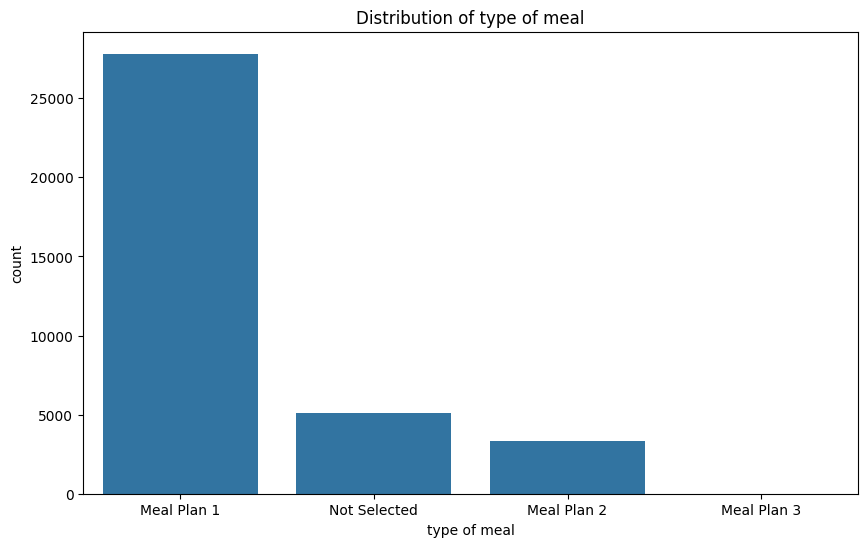

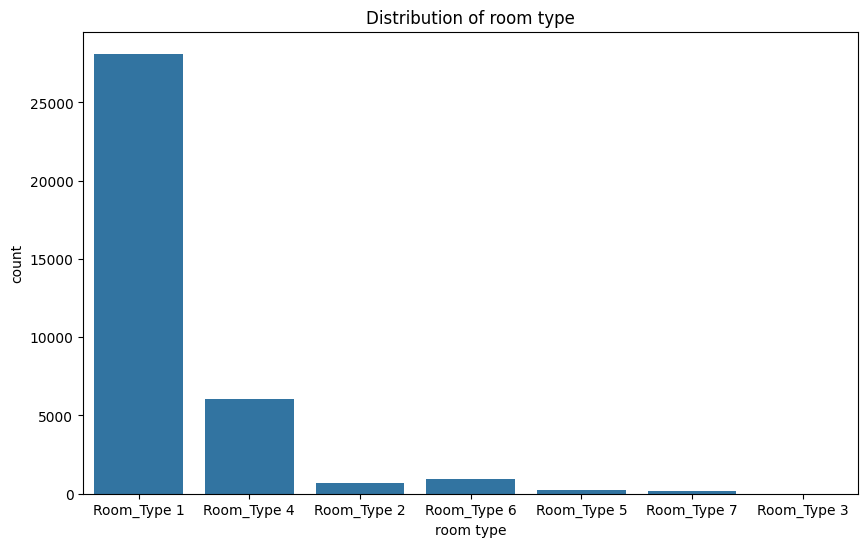

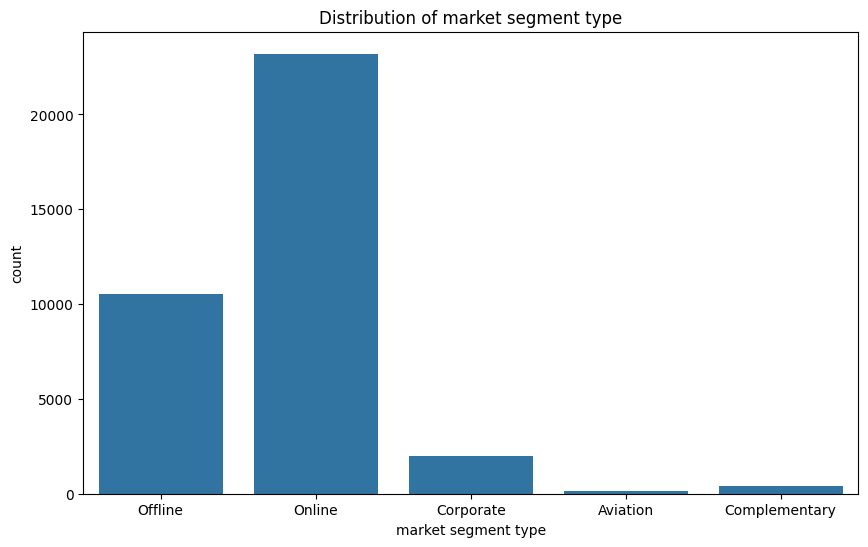

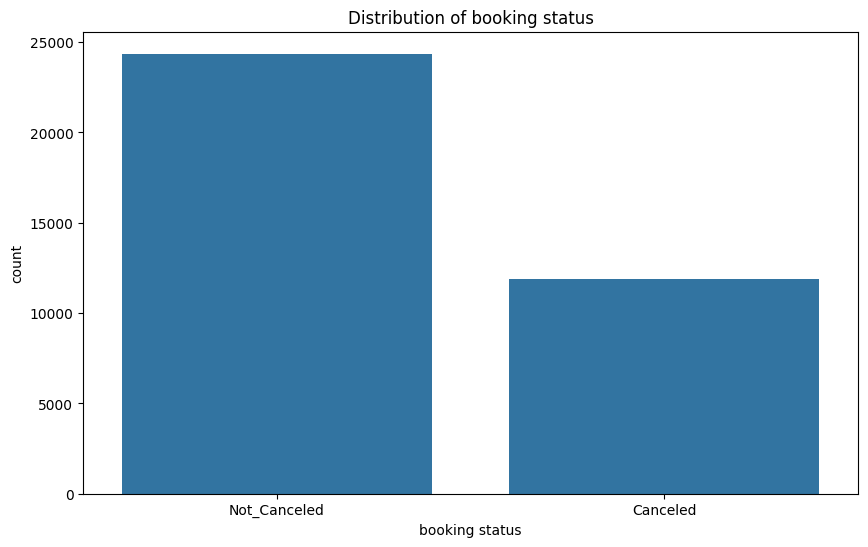

In [ ]:
# Visualize the distribution of categorical feature

for col in df.columns:
    if col in categorical_cols:
        plt.figure(figsize=(10, 6))
        sns.countplot(x=col, data=df)
        plt.title(f"Distribution of {col}")

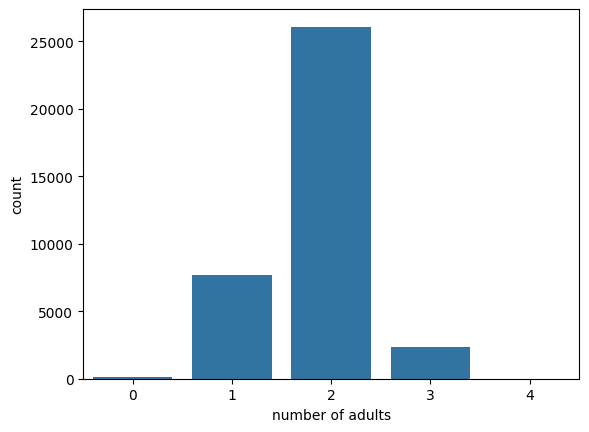

In [ ]:
# Visualize the distribution of the number of adults per booking.
sns.countplot(x="number of adults", data=df)
plt.show()

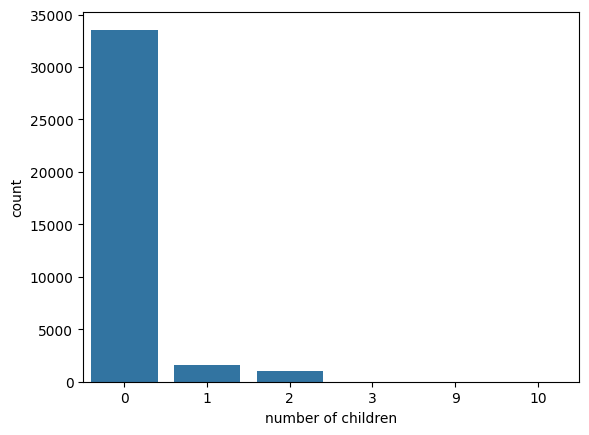

In [ ]:
# Visualize the distribution of the number of children per booking.
sns.countplot(x="number of children", data=df)
plt.show()

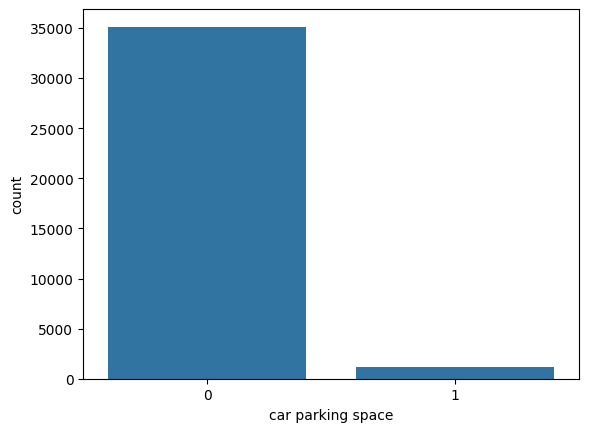

In [ ]:
# Visualize how many bookings requested a car parking space.
sns.countplot(x="car parking space", data=df)
plt.show()

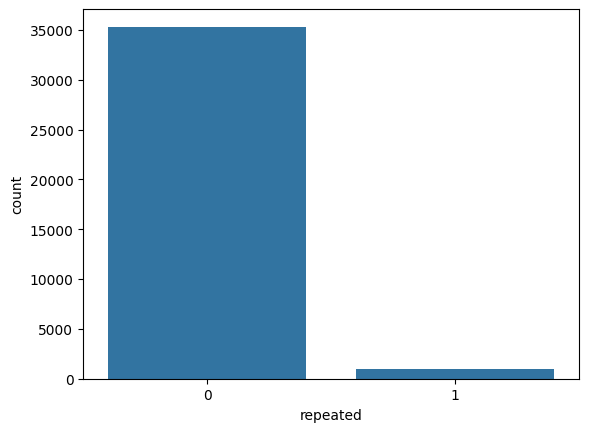

In [ ]:
# Visualize the distribution of repeated and first-time guests.
sns.countplot(x="repeated", data=df)
plt.show()

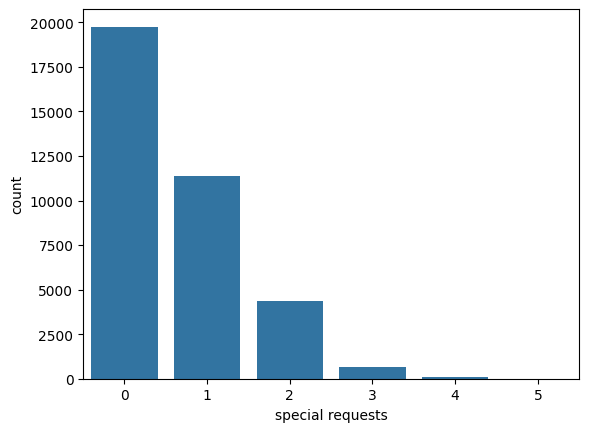

In [ ]:
# Visualize the distribution of special requests made by guests.
sns.countplot(x="special requests", data=df)
plt.show()

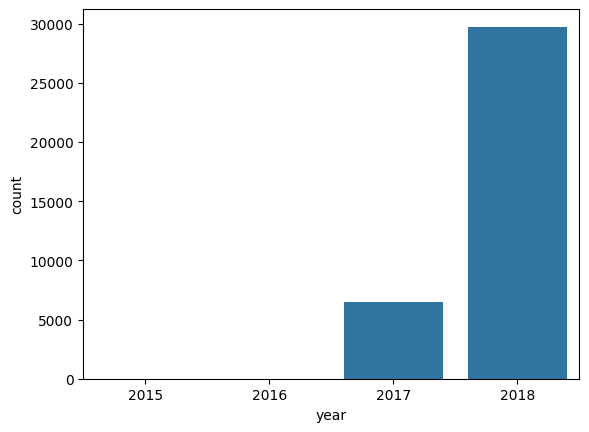

In [ ]:
# Visualize the number of bookings recorded in each year.
sns.countplot(x="year", data=df)
plt.show()

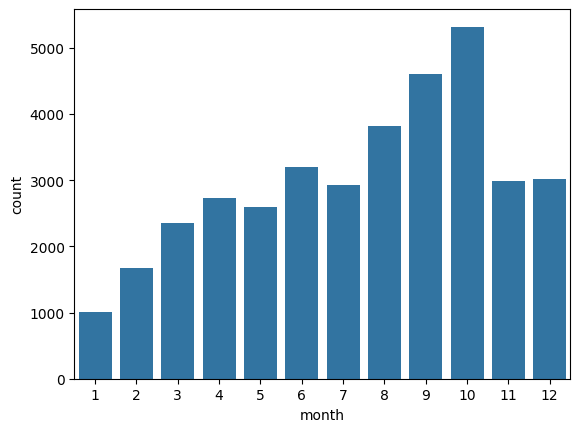

In [ ]:
# Visualize the monthly distribution of hotel bookings.
sns.countplot(x="month", data=df)
plt.show()

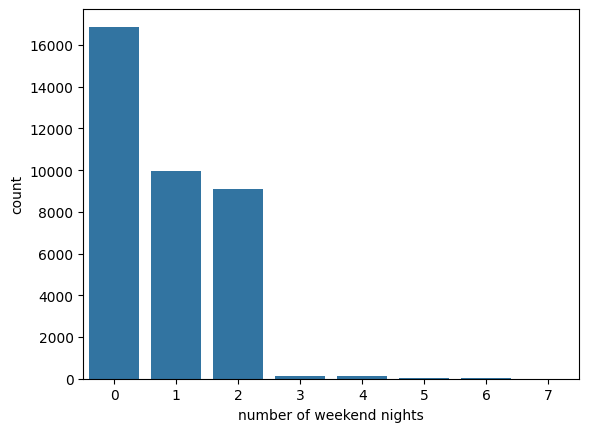

In [ ]:
# Visualize the distribution of weekend nights booked by guests.
sns.countplot(x="number of weekend nights", data=df)
plt.show()

# Second Histplot

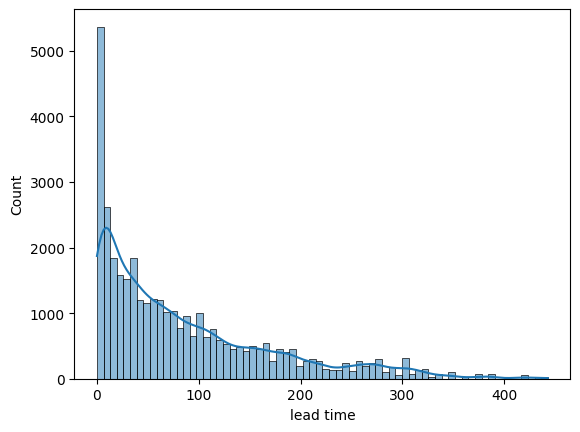

In [ ]:
# Visualize the distribution of lead time.
sns.histplot(x="lead time", data=df, kde=True)
plt.show()

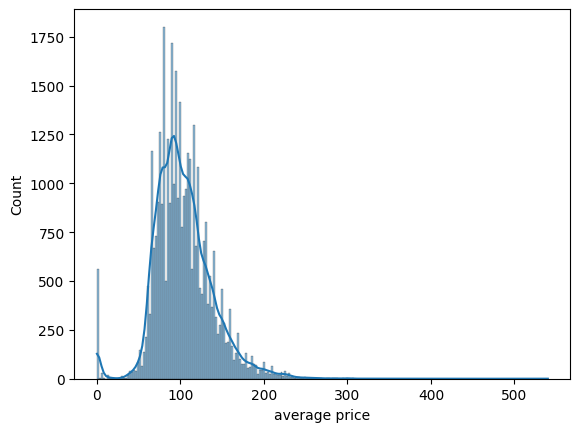

In [ ]:
# Visualize the distribution of the average room price.
sns.histplot(x="average price", data=df, kde=True)
plt.show()

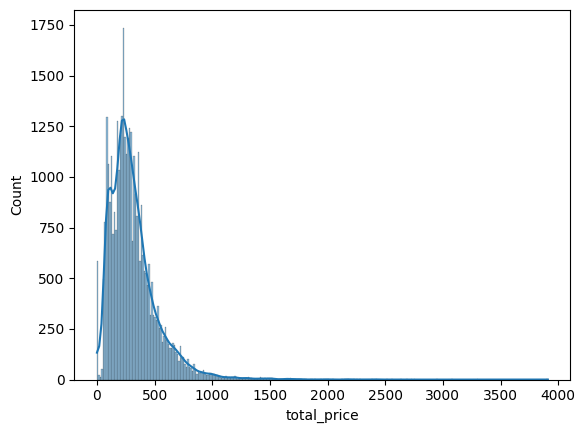

In [ ]:
# Visualize the distribution of the total booking price.
sns.histplot(x="total_price", data=df, kde=True)
plt.show()

# Boxplot

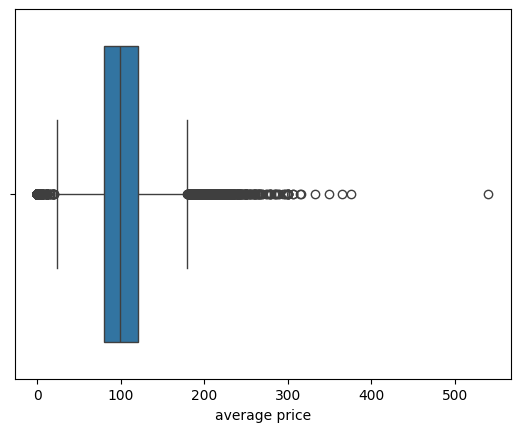

In [ ]:
# Check for outliers in the average room price.
sns.boxplot(x='average price', data=df)
plt.show()

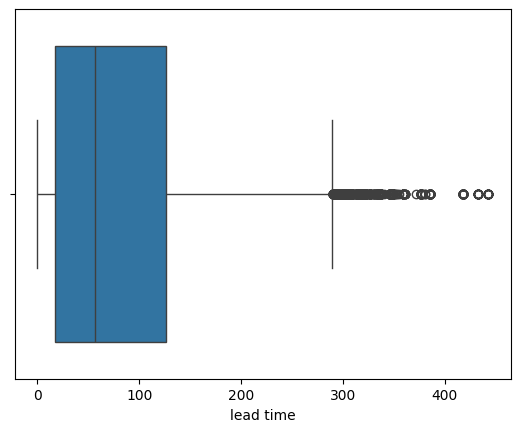

In [ ]:
# Check for outliers in lead time.
sns.boxplot(x='lead time', data=df)
plt.show()

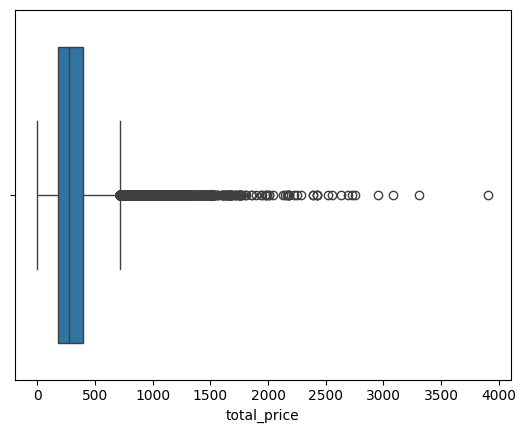

In [ ]:
# Check for outliers in the total booking price.
sns.boxplot(x='total_price', data=df)
plt.show()

# Relationship between each other

In [ ]:
# Analyze the relationship between categorical features and booking status


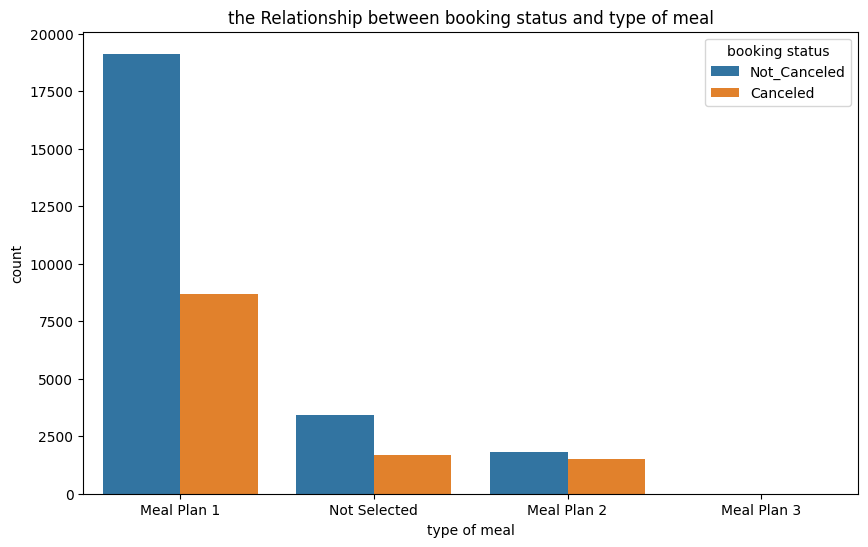

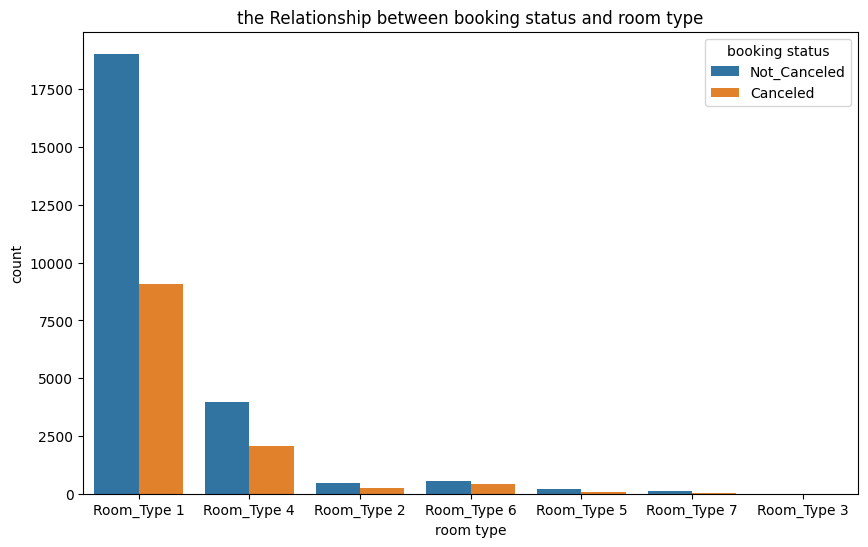

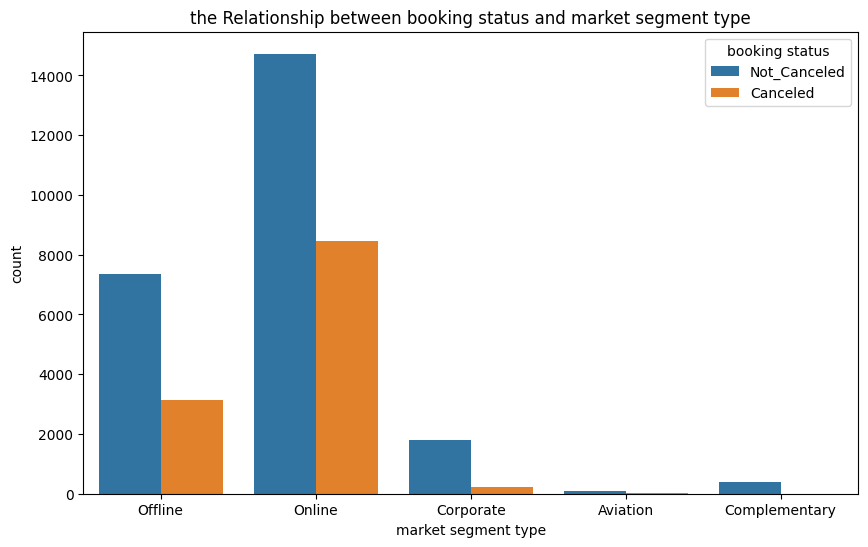

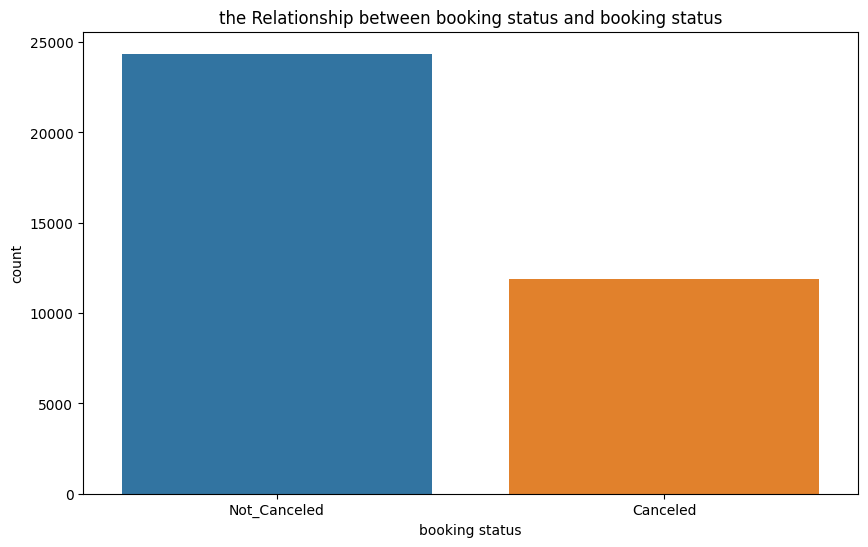

In [ ]:
for col in df.columns:
  if col in categorical_cols:
    plt.figure(figsize=(10,6))
    sns.countplot(x=col,hue='booking status',data=df)
    plt.title(f"the Relationship between booking status and {col}")
    plt.show()

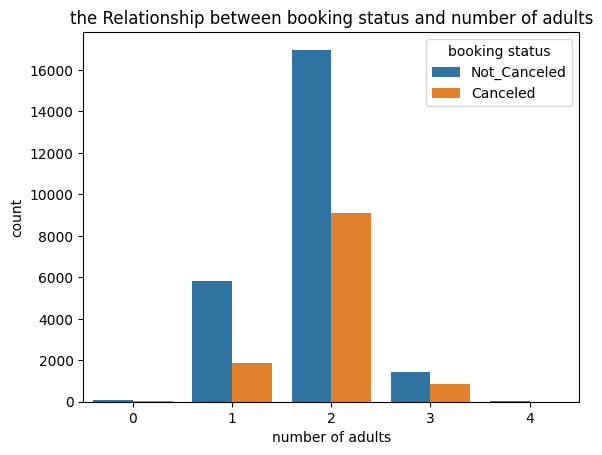

In [ ]:
sns.countplot(x='number of adults',hue='booking status',data=df)
plt.title("the Relationship between booking status and number of adults")
plt.show()

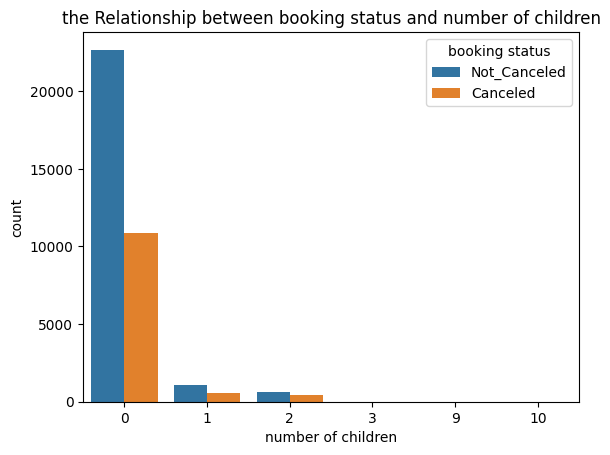

In [ ]:
sns.countplot(x='number of children',hue='booking status',data=df)
plt.title("the Relationship between booking status and number of children")
plt.show()

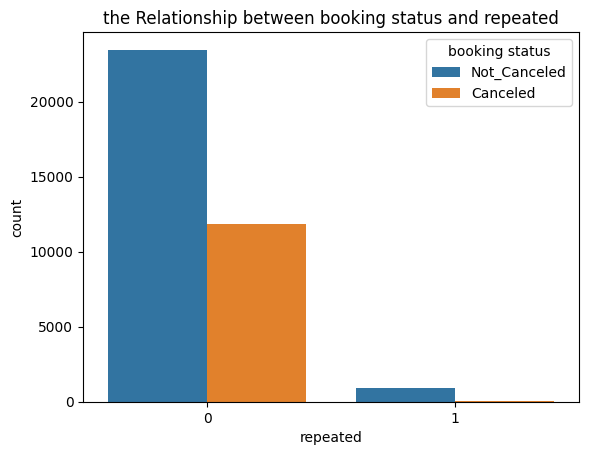

In [ ]:
sns.countplot(x='repeated',hue='booking status',data=df)
plt.title("the Relationship between booking status and repeated")
plt.show()

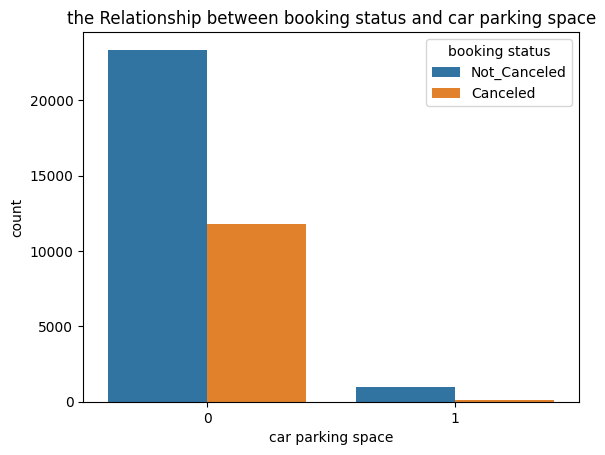

In [ ]:
sns.countplot(x='car parking space',hue='booking status',data=df)
plt.title("the Relationship between booking status and car parking space")
plt.show()

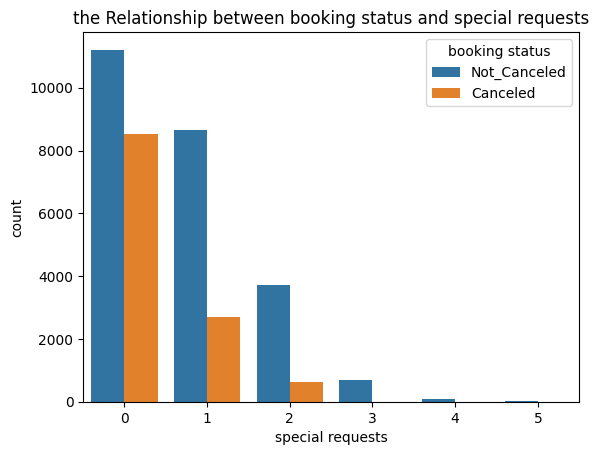

In [ ]:
sns.countplot(x='special requests',hue='booking status',data=df)
plt.title("the Relationship between booking status and special requests")
plt.show()

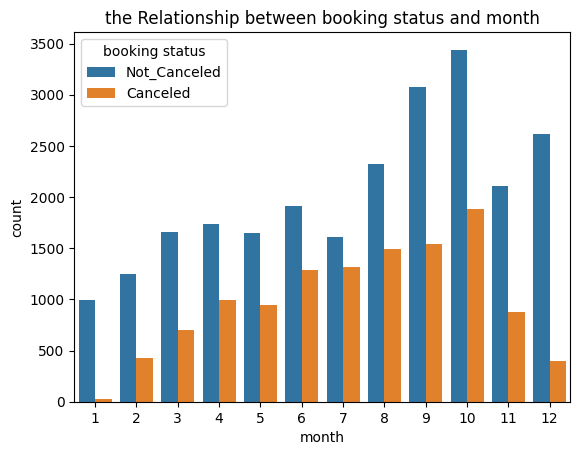

In [ ]:
sns.countplot(x='month',hue='booking status',data=df)
plt.title("the Relationship between booking status and month")
plt.show()


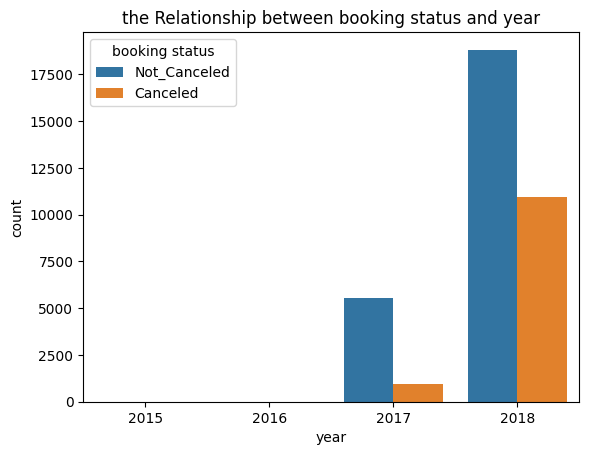

In [ ]:
sns.countplot(x='year',hue='booking status',data=df)
plt.title("the Relationship between booking status and year")
plt.show()

In [ ]:
df.groupby(['year','booking status'])['year'].count()

year  booking status
2015  Not_Canceled          1
2016  Canceled              1
2017  Canceled            962
      Not_Canceled       5554
2018  Canceled          10919
      Not_Canceled      18811
Name: year, dtype: int64

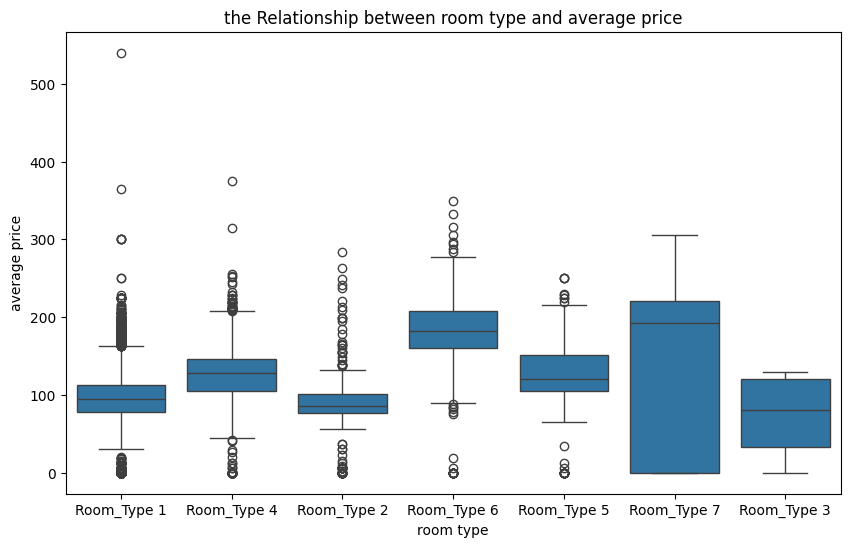

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='room type',y='average price',data=df)
plt.title("the Relationship between room type and average price")
plt.show()

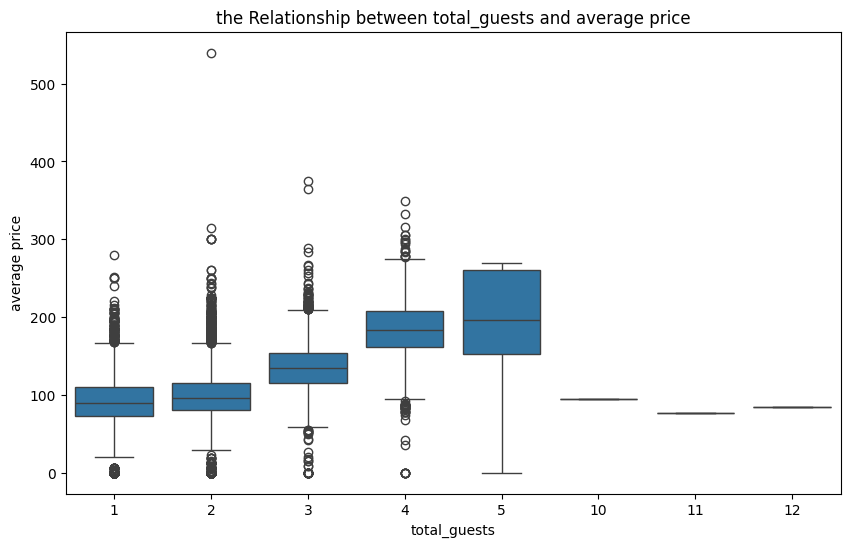

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='total_guests',y='average price',data=df)
plt.title("the Relationship between total_guests and average price")
plt.show()

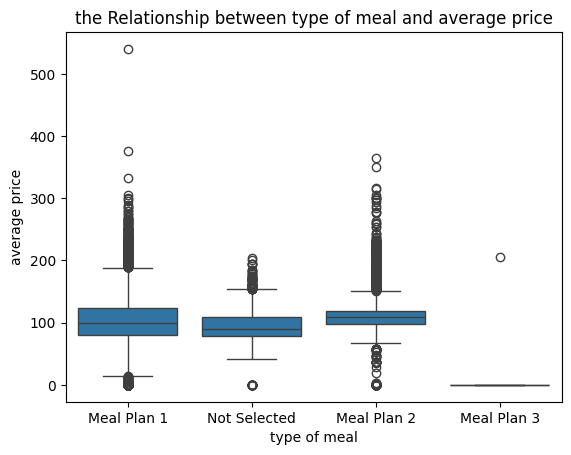

In [ ]:
sns.boxplot(x='type of meal',y='average price',data=df)
plt.title("the Relationship between type of meal and average price")
plt.show()

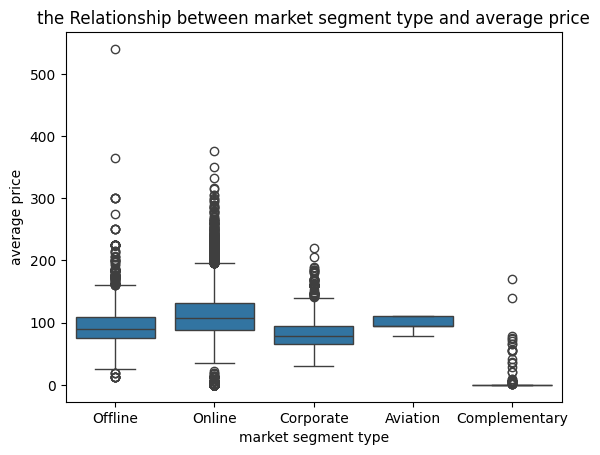

In [ ]:
sns.boxplot(x='market segment type',y='average price',data=df)
plt.title("the Relationship between market segment type and average price")
plt.show()

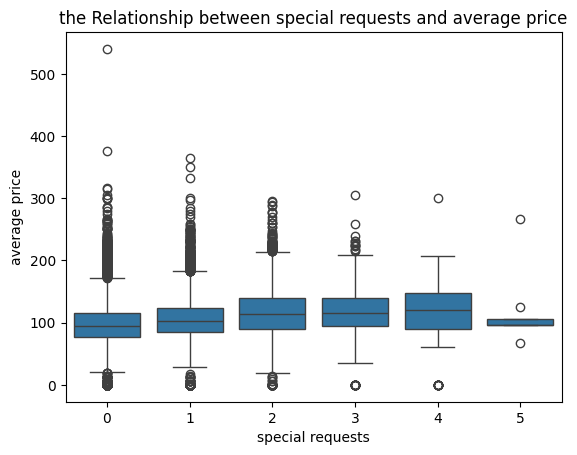

In [ ]:
sns.boxplot(x='special requests',y='average price',data=df)
plt.title("the Relationship between special requests and average price")
plt.show()

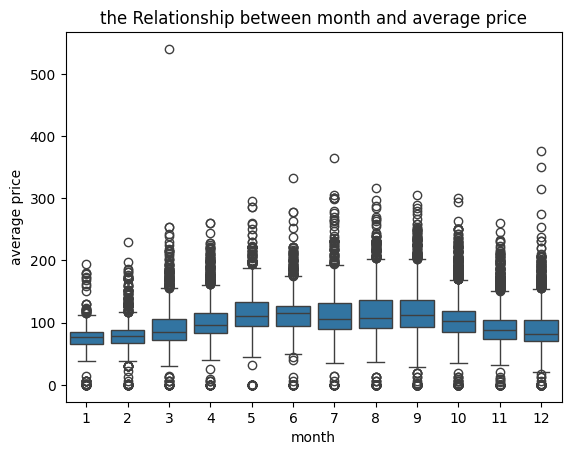

In [ ]:
sns.boxplot(x='month',y='average price',data=df)
plt.title("the Relationship between month and average price")
plt.show()

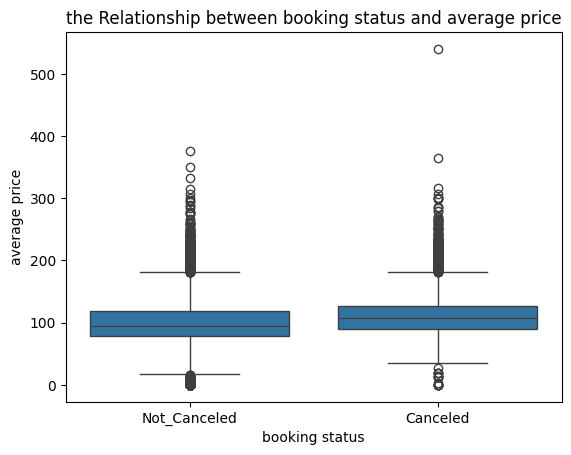

In [ ]:
sns.boxplot(x='booking status',y='average price',data=df)
plt.title("the Relationship between booking status and average price")
plt.show()

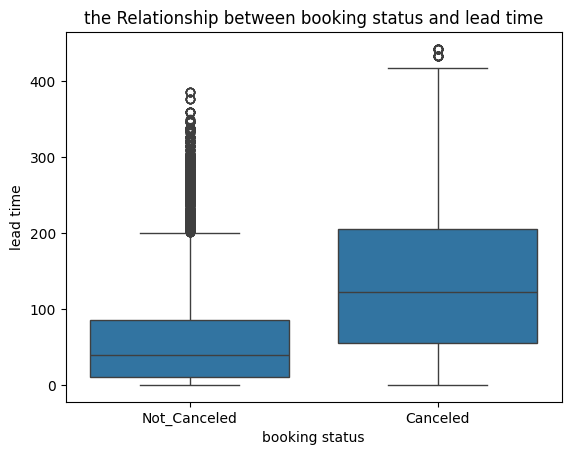

In [ ]:
sns.boxplot(x='booking status',y='lead time',data=df)
plt.title("the Relationship between booking status and lead time")
plt.show()

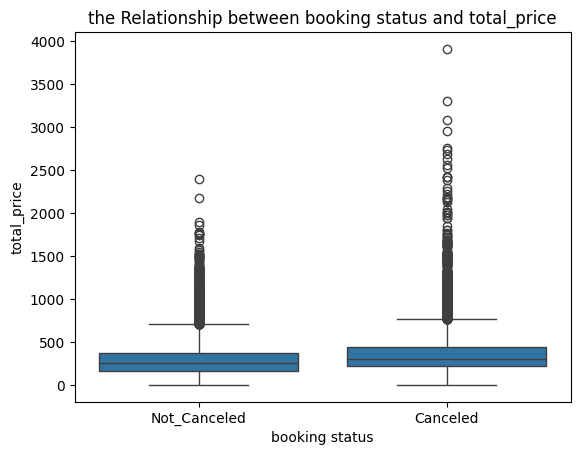

In [ ]:
sns.boxplot(x='booking status',y='total_price',data=df)
plt.title("the Relationship between booking status and total_price")
plt.show()

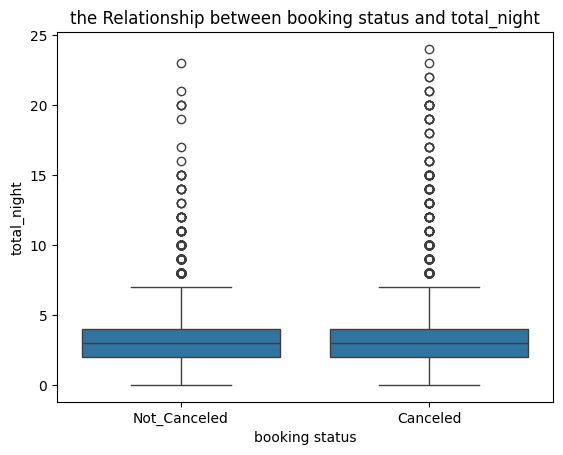

In [ ]:
sns.boxplot(x='booking status',y='total_night',data=df)
plt.title("the Relationship between booking status and total_night")
plt.show()

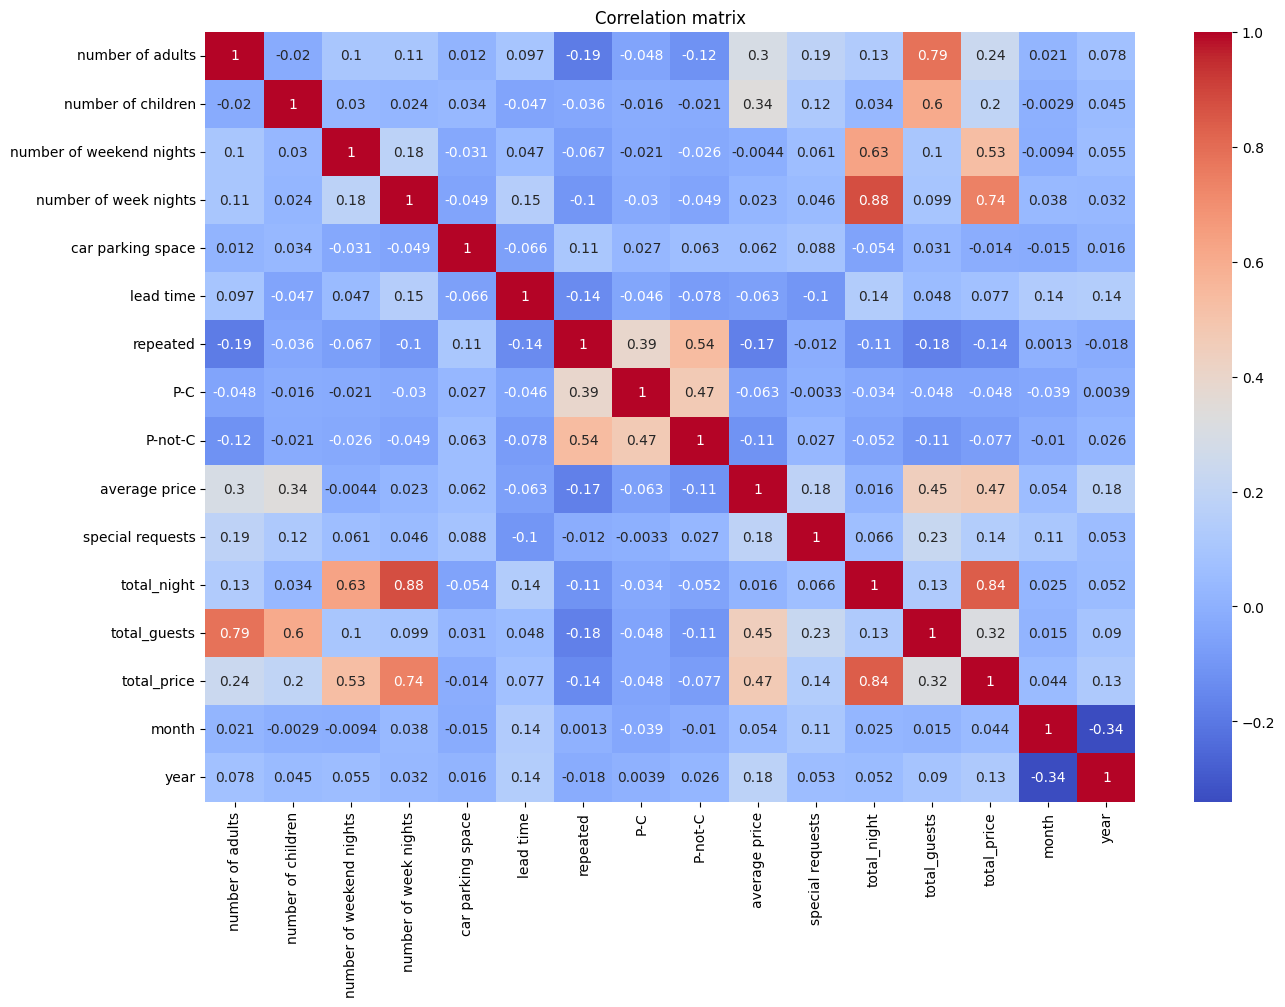

In [ ]:
# heat map
numeric_features =df.select_dtypes(include='number')
corr_matrix =numeric_features.corr()
plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()

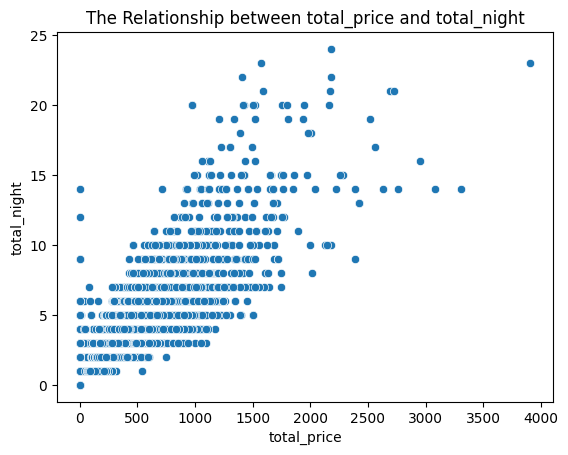

In [ ]:
sns.scatterplot(
    x='total_price',
    y='total_night',
    data=df
)
plt.title("The Relationship between total_price and total_night")
plt.show()

# Encoding

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36248 entries, 0 to 36284
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   number of adults          36248 non-null  int64  
 1   number of children        36248 non-null  int64  
 2   number of weekend nights  36248 non-null  int64  
 3   number of week nights     36248 non-null  int64  
 4   type of meal              36248 non-null  object 
 5   car parking space         36248 non-null  int64  
 6   room type                 36248 non-null  object 
 7   lead time                 36248 non-null  int64  
 8   market segment type       36248 non-null  object 
 9   repeated                  36248 non-null  int64  
 10  P-C                       36248 non-null  int64  
 11  P-not-C                   36248 non-null  int64  
 12  average price             36248 non-null  float64
 13  special requests          36248 non-null  int64  
 14  booking sta

In [ ]:
# label encoder for each categorical coulmn
categorical_cols = df.select_dtypes(include=['object']).columns

label_encoder =LabelEncoder()
for col in categorical_cols:
  df[col] =label_encoder.fit_transform(df[col])

In [ ]:
# display the frequency of each unique values
for col in categorical_cols:
    print(f"\nUnique values in '{col}':")
    print(df[col].value_counts())


Unique values in 'type of meal':
type of meal
0    27809
3     5131
1     3303
2        5
Name: count, dtype: int64

Unique values in 'room type':
room type
0    28113
3     6051
5      964
1      692
4      263
6      158
2        7
Name: count, dtype: int64

Unique values in 'market segment type':
market segment type
4    23201
3    10521
2     2011
1      390
0      125
Name: count, dtype: int64

Unique values in 'booking status':
booking status
1    24366
0    11882
Name: count, dtype: int64


In [ ]:
df.head()

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,booking status,total_night,total_guests,total_price,month,year
0,1,1,2,5,0,0,0,224,3,0,0,0,88.00,0,1,7,2,616.00,10,2015
1,1,0,1,3,3,0,0,5,4,0,0,0,106.68,1,1,4,1,426.72,11,2018
2,2,1,1,3,0,0,0,1,4,0,0,0,50.00,0,0,4,3,200.00,2,2018
3,1,0,0,2,0,0,0,211,4,0,0,0,100.00,1,0,2,1,200.00,5,2017
4,1,0,1,2,3,0,0,48,4,0,0,0,77.00,0,0,3,1,231.00,4,2018


# Train and test

In [ ]:
# Separate the features (X) and the target variable (y)
x=df.drop("booking status",axis=1)
y=df["booking status"]

In [ ]:
# Split the dataset int training and testing
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

# Model

In [ ]:
# the best choice we have was ensemple learning
models = [
    ("decision_tree", DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    )),

    ("random_forest", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )),

    ("xgboost", XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric="logloss"
    ))
]

stacking_model = StackingClassifier(
    estimators=models,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    stack_method="predict_proba"
)

stacking_model.fit(x_train, y_train)

y_pred = stacking_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9004137931034483
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      2369
           1       0.91      0.94      0.93      4881

    accuracy                           0.90      7250
   macro avg       0.89      0.88      0.88      7250
weighted avg       0.90      0.90      0.90      7250



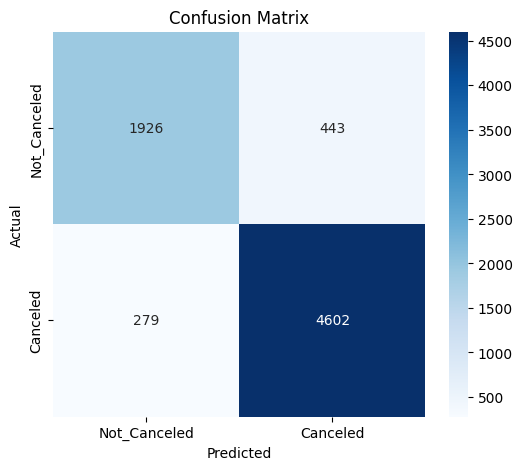

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not_Canceled", "Canceled"],
    yticklabels=["Not_Canceled", "Canceled"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()